# Credit Applications EDA

Load both source tables, inspect their quality, and explore application behavior over time and by customer risk group.

## Imports

In [85]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
sns.set_theme(style='whitegrid', palette='deep')

## Display raw data

In [86]:
# Load the raw datasets, skipping the first column (index column from CSV export).
credit_applications = pd.read_csv('./data/credit_applications.csv', index_col=0)
customers = pd.read_csv('./data/customers.csv', index_col=0)

# Convert YYYYMM to a proper month-period value (year-month only, no day).
for dataframe in (credit_applications, customers):
    dataframe["yearmonth"] = pd.to_datetime(dataframe["yearmonth"].astype(str), format="%Y%m").dt.to_period("M")

In [87]:
print(f'credit_applications: {credit_applications.shape[0]} rows x {credit_applications.shape[1]} columns')
display(credit_applications)

credit_applications: 29996 rows x 4 columns


,client_nr,yearmonth,credit_application,nr_credit_applications
1,1,2014-01,0,0
2,1,2014-02,0,0
3,1,2014-03,0,0
4,1,2014-04,0,0
5,1,2014-05,0,0
...,...,...,...,...
29992,1000,2016-04,0,0
29993,1000,2016-05,0,0
29994,1000,2016-06,0,0
29995,1000,2016-07,0,0


In [88]:
print(f'customers: {customers.shape[0]} rows x {customers.shape[1]} columns')
display(customers)

customers: 29996 rows x 10 columns


,client_nr,yearmonth,total_nr_trx,nr_debit_trx,volume_debit_trx,nr_credit_trx,volume_credit_trx,min_balance,max_balance,CRG
1,1,2014-01,97,50,6527929,47,7454863,-7914288,25110651,1.00
2,1,2014-02,88,59,3475918,29,1895848,-8448513,25036651,1.00
3,1,2014-03,96,62,31316405,34,20083583,-10347650,18020151,1.00
4,1,2014-04,83,53,18669967,30,1091295,-15385039,13318200,1.00
5,1,2014-05,94,54,2893905,40,2034075,-15682170,2350000,1.00
...,...,...,...,...,...,...,...,...,...,...
29992,1000,2016-04,2,1,605000,1,315800,131422,736422,NaN
29993,1000,2016-05,5,3,607506,2,1210000,128916,735145,NaN
29994,1000,2016-06,4,3,1211270,1,605000,127646,1338916,NaN
29995,1000,2016-07,4,2,606253,2,920000,441393,1047646,NaN


## Data quality and structure

In [89]:
def quality_report(dataframe, name):
    """Display a concise data-quality report for a DataFrame.

    The report includes the DataFrame dimensions, column data types,
    missing-value counts and ratios, duplicate-row count, and summary
    statistics for numeric and categorical columns.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        DataFrame to profile.
    name : str
        Label displayed with the DataFrame dimensions.
    """
    print(f"{name}: {dataframe.shape[0]:,} rows x {dataframe.shape[1]} columns")

    print("\nColumn data types")
    display(dataframe.dtypes.rename("dtype").to_frame())

    print("\nMissing values")
    missing = dataframe.isna().sum().rename("missing_values").to_frame()
    missing["missing_ratio"] = missing["missing_values"].div(len(dataframe)).fillna(0)
    display(missing[missing["missing_values"] > 0].sort_values("missing_ratio", ascending=False))

    print(f"\nDuplicate rows: {dataframe.duplicated().sum():,}")

    print("\nSummary statistics")
    display(dataframe.describe(include="all").T)


### Quality report Credit applications table

In [90]:
quality_report(credit_applications, "Credit applications")

Credit applications: 29,996 rows x 4 columns

Column data types


,dtype
client_nr,int64
yearmonth,period[M]
credit_application,int64
nr_credit_applications,int64



Missing values


,missing_values,missing_ratio



Duplicate rows: 0

Summary statistics


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
client_nr,"29,996.00",NaN,NaT,NaN,481.56,281.32,1.00,237.00,479.00,721.00,"1,000.00"
yearmonth,29996,32,2016-01,943,NaN,NaN,NaN,NaN,NaN,NaN,NaN
credit_application,"29,996.00",NaN,NaT,NaN,0.07,0.25,0.00,0.00,0.00,0.00,1.00
nr_credit_applications,"29,996.00",NaN,NaT,NaN,0.09,0.36,0.00,0.00,0.00,0.00,7.00


### Quality report Customers table

In [91]:
quality_report(customers, "Customers")

Customers: 29,996 rows x 10 columns

Column data types


,dtype
client_nr,int64
yearmonth,period[M]
total_nr_trx,int64
nr_debit_trx,int64
volume_debit_trx,int64
nr_credit_trx,int64
volume_credit_trx,int64
min_balance,int64
max_balance,int64
CRG,float64



Missing values


,missing_values,missing_ratio
CRG,5537,0.18



Duplicate rows: 0

Summary statistics


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
client_nr,"29,996.00",NaN,NaT,NaN,481.56,281.32,1.00,237.00,479.00,721.00,"1,000.00"
yearmonth,29996,32,2016-01,943,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_nr_trx,"29,996.00",NaN,NaT,NaN,166.43,220.95,1.00,76.00,129.00,205.00,"6,341.00"
nr_debit_trx,"29,996.00",NaN,NaT,NaN,75.79,60.06,0.00,38.00,66.00,101.00,"1,590.00"
volume_debit_trx,"29,996.00",NaN,NaT,NaN,"11,212,898.00","16,175,957.73",0.00,"3,072,750.25","6,822,769.00","13,866,561.25","798,047,977.00"
nr_credit_trx,"29,996.00",NaN,NaT,NaN,90.64,192.24,0.00,33.00,56.00,102.00,"6,325.00"
volume_credit_trx,"29,996.00",NaN,NaT,NaN,"11,269,063.11","16,249,981.84",0.00,"3,148,067.50","6,934,694.00","13,942,573.00","877,532,140.00"
min_balance,"29,996.00",NaN,NaT,NaN,"-5,523,773.38","13,575,174.77","-346,712,718.00","-7,895,863.50","-2,957,198.00","16,902.75","210,978,316.00"
max_balance,"29,996.00",NaN,NaT,NaN,"3,752,692.59","16,169,373.88","-248,520,614.00","-1,868,001.50","1,040,997.50","5,806,224.00","372,231,851.00"
CRG,"24,459.00",NaN,NaT,NaN,3.25,1.89,1.00,2.00,3.00,4.00,7.00


## Validate documented column logic

Before combining the tables, validate the relationships described in the source documentation. First, check that the application flag and application count agree. Then, check that the customer transaction and balance fields are internally consistent.

The `credit_application` field should be `1` whenever `nr_credit_applications` is greater than `0`, and otherwise `0`. The first check below tests both directions of this relationship.

In [92]:
# Check whether the application flag agrees with the application count.
credit_applications_issue1 = credit_applications[
    (credit_applications["nr_credit_applications"] == 0)
    & (credit_applications["credit_application"] > 0)
]
num_rows_issue1 = credit_applications_issue1.shape[0]

credit_applications_issue2 = credit_applications[
    (credit_applications["nr_credit_applications"] > 0)
    & (credit_applications["credit_application"] == 0)
]
num_rows_issue2 = credit_applications_issue2.shape[0]

print(f"Issue 1 - application flag is 1, but application count is 0: {num_rows_issue1} rows")
print(f"Issue 2 - application count is positive, but application flag is 0: {num_rows_issue2} rows")

if num_rows_issue1 > 0 or num_rows_issue2 > 0:
    print("Issues found in the application flag and count relationship.")
else:
    print("No issues found in the application flag and count relationship.")

Issue 1 - application flag is 1, but application count is 0: 0 rows
Issue 2 - application count is positive, but application flag is 0: 0 rows
No issues found in the application flag and count relationship.


In [93]:
# Check whether debit transaction counts and volumes are logically consistent.
debit_transactions_issue = customers[
    ((customers["nr_debit_trx"] > 0) & (customers["volume_debit_trx"] == 0))
    | ((customers["volume_debit_trx"] > 0) & (customers["nr_debit_trx"] == 0))
]
num_rows_debit_issue = debit_transactions_issue.shape[0]

# Check whether credit transaction counts and volumes are logically consistent.
credit_transactions_issue = customers[
    ((customers["nr_credit_trx"] > 0) & (customers["volume_credit_trx"] == 0))
    | ((customers["volume_credit_trx"] > 0) & (customers["nr_credit_trx"] == 0))
]
num_rows_credit_issue = credit_transactions_issue.shape[0]

# Check that minimum balances do not exceed maximum balances.
balance_issue = customers[customers["min_balance"] > customers["max_balance"]]
num_rows_balance_issue = balance_issue.shape[0]


# Check that total transactions equal debit transactions plus credit transactions.
total_transactions_issue = customers[
    customers["total_nr_trx"] != customers["nr_debit_trx"] + customers["nr_credit_trx"]
]
num_rows_total_transactions_issue = total_transactions_issue.shape[0]

print(f"Debit transaction count/volume issue: {num_rows_debit_issue} rows")
print(f"Credit transaction count/volume issue: {num_rows_credit_issue} rows")
print(f"Minimum/maximum balance issue: {num_rows_balance_issue} rows")
print(f"Total transaction count issue: {num_rows_total_transactions_issue} rows")

if any(
    (
        num_rows_debit_issue,
        num_rows_credit_issue,
        num_rows_balance_issue,
        num_rows_total_transactions_issue,
    )
):
    print("Issues found in customer transaction and balance data.")
else:
    print("No issues found in customer transaction and balance data.")

Debit transaction count/volume issue: 0 rows
Credit transaction count/volume issue: 0 rows
Minimum/maximum balance issue: 0 rows
Total transaction count issue: 0 rows
No issues found in customer transaction and balance data.


### Check whether each client has a row for every month

The following validation checks that every client appears at least once in each month in the observed range for both source tables.



In [94]:
def missing_client_ids_by_yearmonth(dataframe, name=None):
    """Return which client IDs are missing for each yearmonth.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Table containing at least the columns `client_nr` and `yearmonth`.
    name : str, optional
        Label used only for printed output.

    Returns
    -------
    dict[int, list[int]]
        Mapping from integer yearmonth to the list of client IDs missing in that month.
    """

    df = dataframe[["client_nr", "yearmonth"]].drop_duplicates().copy()
    df["client_nr"] = df["client_nr"].astype(int)

    all_clients = sorted(df["client_nr"].unique())
    all_months = sorted(df["yearmonth"].unique())

    missing_by_month = {}
    for yearmonth in all_months:
        observed_clients = set(df.loc[df["yearmonth"] == yearmonth, "client_nr"])
        missing_clients = sorted(set(all_clients) - observed_clients)
        missing_by_month[yearmonth] = missing_clients

    if name:
        print(f"{name}: missing client IDs by yearmonth")
        for yearmonth, client_ids in missing_by_month.items():
            print(f"  {yearmonth}: {len(client_ids)} clients missing -> {client_ids[:10]}" + (" ..." if len(client_ids) > 10 else ""))

    return missing_by_month


def summarize_missing_clients(dataframe, name=None):
    """Summarize missing client coverage by month and by client.

    Returns
    -------
    dict
        {
            'missing_clients_by_yearmonth': {yearmonth: [client_ids...]},
            'missing_count_by_yearmonth': {yearmonth: count},
            'missing_count_by_client': {client_id: count_of_missing_yearmonths}
        }
    """
    missing_by_month = missing_client_ids_by_yearmonth(dataframe, name=name)

    # Count how many clients are missing in each month.
    missing_count_by_yearmonth = {
        yearmonth: len(client_ids)
        for yearmonth, client_ids in missing_by_month.items()
    }

    # Count how many months each client is missing.
    missing_count_by_client = {}
    for client_ids in missing_by_month.values():
        for client_id in client_ids:
            missing_count_by_client[client_id] = missing_count_by_client.get(client_id, 0) + 1

    if name:
        print(f"{name}: missing counts by yearmonth")
        for yearmonth, count in missing_count_by_yearmonth.items():
            print(f"  {yearmonth}: {count} clients missing")

        print(f"\n{name}: missing counts by client")
        for client_id, count in sorted(missing_count_by_client.items()):
            print(f"  {client_id}: {count} months missing")

    return {
        "missing_clients_by_yearmonth": missing_by_month,
        "missing_count_by_yearmonth": missing_count_by_yearmonth,
        "missing_count_by_client": dict(sorted(missing_count_by_client.items())),
    }




In [95]:

credit_applications_missing = missing_client_ids_by_yearmonth(credit_applications, "Credit applications")
customers_missing = missing_client_ids_by_yearmonth(customers, "Customers")

credit_applications_summary = summarize_missing_clients(credit_applications, "Credit applications")
customers_summary = summarize_missing_clients(customers, "Customers")


Credit applications: missing client IDs by yearmonth
  2014-01: 62 clients missing -> [68, 256, 377, 378, 433, 474, 561, 786, 826, 858] ...
  2014-02: 61 clients missing -> [256, 377, 378, 433, 474, 561, 786, 826, 858, 863] ...
  2014-03: 61 clients missing -> [68, 196, 256, 377, 378, 433, 561, 786, 826, 858] ...
  2014-04: 60 clients missing -> [256, 377, 378, 433, 494, 561, 786, 826, 858, 863] ...
  2014-05: 60 clients missing -> [196, 256, 377, 433, 474, 494, 561, 786, 826, 836] ...
  2014-06: 60 clients missing -> [68, 256, 348, 377, 433, 474, 494, 561, 786, 826] ...
  2014-07: 56 clients missing -> [68, 256, 377, 433, 474, 494, 561, 786, 826, 863] ...
  2014-08: 57 clients missing -> [68, 196, 256, 377, 433, 474, 494, 561, 786, 826] ...
  2014-09: 57 clients missing -> [68, 196, 256, 348, 377, 433, 474, 494, 561, 786] ...
  2014-10: 51 clients missing -> [68, 256, 433, 494, 561, 786, 826, 842, 879, 894] ...
  2014-11: 54 clients missing -> [196, 256, 348, 377, 433, 465, 561, 786, 

In [96]:
print("\nTop 5 credit applications months by missing clients:")
for yearmonth, count in list(credit_applications_summary["missing_count_by_yearmonth"].items())[:5]:
    print(f"  yearmonth {yearmonth}: {count} clients missing")

print("\nTop 5 customer months by missing clients:")
for yearmonth, count in list(customers_summary["missing_count_by_yearmonth"].items())[:5]:
    print(f"  yearmonth {yearmonth}: {count} clients missing")

print("\nTop 5 credit applications clients by missing months:")
for client_id, count in list(credit_applications_summary["missing_count_by_client"].items())[:5]:
    print(f"  client_id {client_id}: {count} months missing")

print("\nTop 5 customer clients by missing months:")
for client_id, count in list(customers_summary["missing_count_by_client"].items())[:5]:
    print(f"  client_id {client_id}: {count} months missing")


Top 5 credit applications months by missing clients:
  yearmonth 2014-01: 62 clients missing
  yearmonth 2014-02: 61 clients missing
  yearmonth 2014-03: 61 clients missing
  yearmonth 2014-04: 60 clients missing
  yearmonth 2014-05: 60 clients missing

Top 5 customer months by missing clients:
  yearmonth 2014-01: 62 clients missing
  yearmonth 2014-02: 61 clients missing
  yearmonth 2014-03: 61 clients missing
  yearmonth 2014-04: 60 clients missing
  yearmonth 2014-05: 60 clients missing

Top 5 credit applications clients by missing months:
  client_id 68: 28 months missing
  client_id 81: 2 months missing
  client_id 97: 6 months missing
  client_id 140: 1 months missing
  client_id 173: 3 months missing

Top 5 customer clients by missing months:
  client_id 68: 28 months missing
  client_id 81: 2 months missing
  client_id 97: 6 months missing
  client_id 140: 1 months missing
  client_id 173: 3 months missing


In [97]:
# Compare the missing client/month combinations across both tables.
credit_applications_missing_pairs = {
    (yearmonth, client_id)
    for yearmonth, client_ids in credit_applications_missing.items()
    for client_id in client_ids
}
customers_missing_pairs = {
    (yearmonth, client_id)
    for yearmonth, client_ids in customers_missing.items()
    for client_id in client_ids
}

same_missing_pairs = credit_applications_missing_pairs == customers_missing_pairs
print(f"Same missing client/month pairs in both tables: {same_missing_pairs}")

if not same_missing_pairs:
    only_in_credit_applications = sorted(credit_applications_missing_pairs - customers_missing_pairs)
    only_in_customers = sorted(customers_missing_pairs - credit_applications_missing_pairs)

    print(f"Only in credit_applications: {len(only_in_credit_applications)}")
    print(only_in_credit_applications[:10])

    print(f"Only in customers: {len(only_in_customers)}")
    print(only_in_customers[:10])
else:
    print("The missing client/month rows are identical in both tables.")


Same missing client/month pairs in both tables: True
The missing client/month rows are identical in both tables.


### Key validation and table merge

The two tables are joined by `client_nr` and `yearmonth`. Before merging, verify that this combination identifies at most one row in each table. A one-to-one merge then combines the application outcome with the corresponding customer information.

In [98]:
key_columns = ['client_nr', 'yearmonth']

# Check that client_nr + yearmonth identifies at most one row in each table.
credit_application_duplicate_keys = credit_applications.duplicated(key_columns).sum()
customer_duplicate_keys = customers.duplicated(key_columns).sum()
print(f'Credit application duplicate keys: {credit_application_duplicate_keys}')
print(f'Customer duplicate keys: {customer_duplicate_keys}')

# Merge the validated tables and require a one-to-one relationship.
eda = credit_applications.merge(
    customers,
    on=key_columns,
    how='inner',
    validate='one_to_one',
    suffixes=('_application', '_customer'),
)
print(f'Merged rows: {len(eda)}')
display(eda.head())

Credit application duplicate keys: 0
Customer duplicate keys: 0
Merged rows: 29996


,client_nr,yearmonth,credit_application,nr_credit_applications,total_nr_trx,nr_debit_trx,volume_debit_trx,nr_credit_trx,volume_credit_trx,min_balance,max_balance,CRG
0,1,2014-01,0,0,97,50,6527929,47,7454863,-7914288,25110651,1.00
1,1,2014-02,0,0,88,59,3475918,29,1895848,-8448513,25036651,1.00
2,1,2014-03,0,0,96,62,31316405,34,20083583,-10347650,18020151,1.00
3,1,2014-04,0,0,83,53,18669967,30,1091295,-15385039,13318200,1.00
4,1,2014-05,0,0,94,54,2893905,40,2034075,-15682170,2350000,1.00


### Distinguish true missing rows from onboarding gaps

For each client, we check whether the missing months are only before the first observed month (possible onboarding) or whether there are any missing months after the client has already started appearing in the data (likely genuine data gaps).


In [99]:
# Build a monthly timeline per client in the merged table.
# We only need the key columns for this validation.
client_months = eda[["client_nr", "yearmonth"]].drop_duplicates().copy()

# Sort the data so month order is meaningful for each client.
client_months = client_months.sort_values(["client_nr", "yearmonth"]).reset_index(drop=True)

# For each client, determine whether the missing months happen only before the first observed month
# or whether there are gaps after the client has already started producing records.
# A client with no historical data at all is treated as a likely onboarding case, not a true gap.
missing_pattern = []
for client_id, group in client_months.groupby("client_nr"):
    months = sorted(group["yearmonth"].unique())
    if len(months) <= 1:
        missing_pattern.append({
            "client_nr": client_id,
            "first_observed_month": months[0] if months else None,
            "has_true_gap": False,
            "reason": "single-month or no-gap client",
            "missing_months_before_first_observation": [],
            "missing_months_after_first_observation": [],
        })
        continue

    month_range = pd.period_range(start=months[0], end=months[-1], freq="M")
    observed_set = set(months)
    missing_all = sorted(set(month_range) - observed_set)

    missing_before_first = [m for m in missing_all if m < months[0]]
    missing_after_first = [m for m in missing_all if m > months[0]]

    # If all missing months occur before any observed month, the client likely was not onboarded yet.
    # If any missing month occurs after the client already has historical data, this is a true gap.
    has_true_gap = bool(missing_after_first)

    missing_pattern.append({
        "client_nr": client_id,
        "first_observed_month": months[0],
        "has_true_gap": has_true_gap,
        "reason": "onboarding gap" if not has_true_gap else "true data gap",
        "missing_months_before_first_observation": missing_before_first,
        "missing_months_after_first_observation": missing_after_first,
    })

missing_pattern_df = pd.DataFrame(missing_pattern)

print("Clients with genuine missing rows after onboarding:")
true_gap_clients = missing_pattern_df[missing_pattern_df["has_true_gap"]]
print(true_gap_clients[["client_nr", "first_observed_month", "missing_months_after_first_observation"]].head(10).to_string(index=False))

print("\nClients with only onboarding-style gaps before first observation:")
onboarding_clients = missing_pattern_df[~missing_pattern_df["has_true_gap"]]
print(onboarding_clients[["client_nr", "first_observed_month", "missing_months_before_first_observation"]].head(10).to_string(index=False))

print(f"\nTotal clients with true gaps: {len(true_gap_clients)}")
print(f"Total clients with onboarding-only gaps: {len(onboarding_clients)}")


Clients with genuine missing rows after onboarding:
 client_nr first_observed_month                                                              missing_months_after_first_observation
        68              2014-02                                              [2014-03, 2014-06, 2014-07, 2014-08, 2014-09, 2014-10]
       140              2014-01                                                                                           [2016-04]
       173              2014-01                                                                                           [2016-04]
       196              2014-01          [2014-03, 2014-05, 2014-08, 2014-09, 2014-11, 2014-12, 2015-02, 2015-03, 2015-05, 2015-06]
       219              2014-01                                                                                  [2016-06, 2016-07]
       284              2014-01                                              [2015-10, 2015-11, 2015-12, 2016-02, 2016-04, 2016-05]
       315              

## Distributions, application rates, and time trends

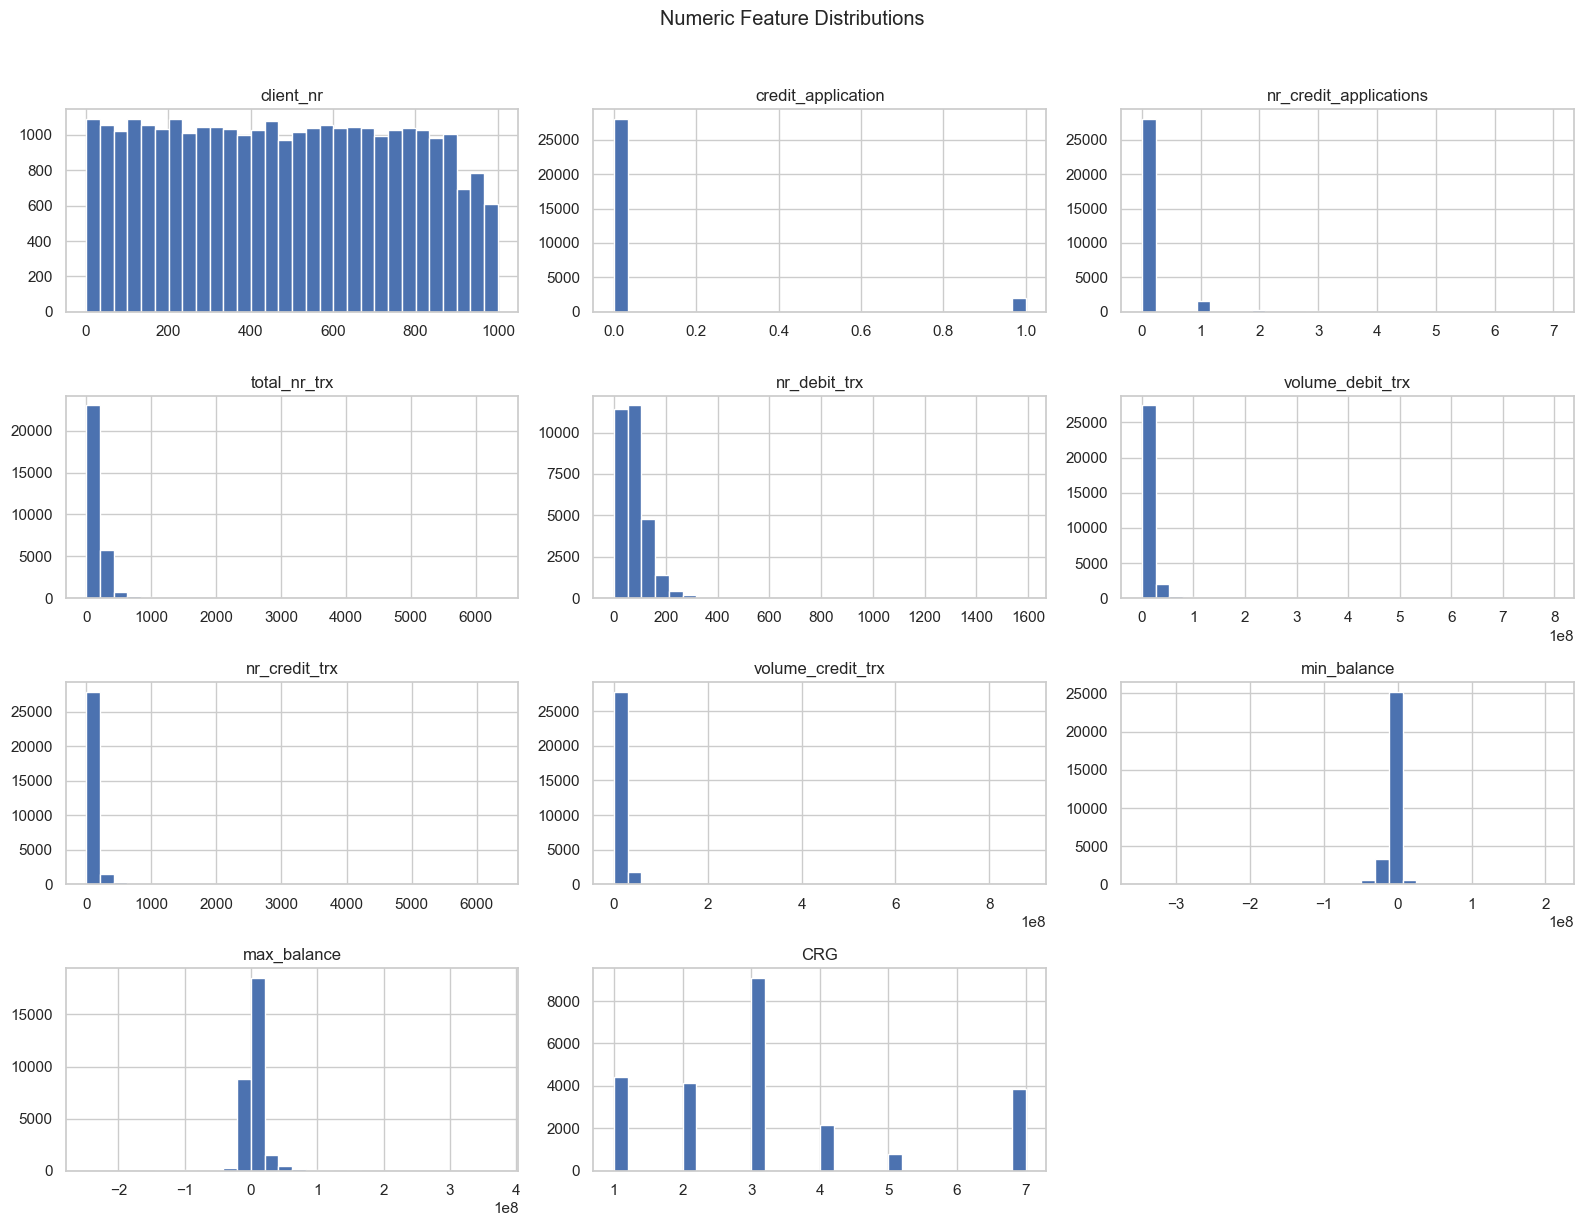

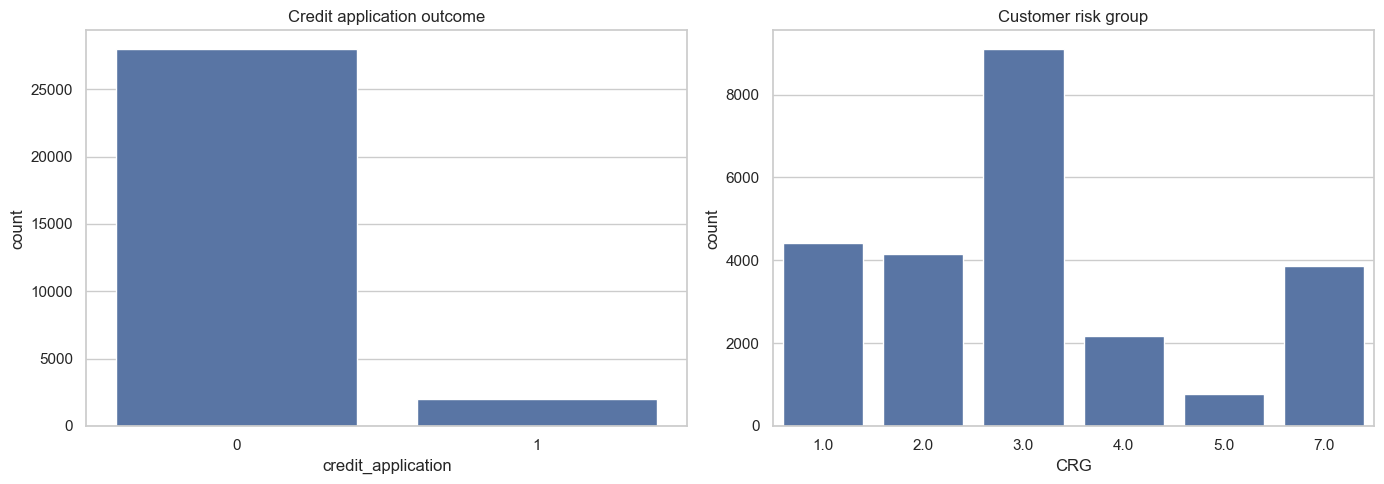

,application_rate,observations,applications
CRG,,,
5.00,0.14,778,111
7.00,0.12,3858,479
4.00,0.11,2161,232
2.00,0.07,4141,305
3.00,0.07,9097,607
1.00,0.03,4424,149
NaN,0.03,5537,142


In [100]:
numeric_columns = eda.select_dtypes(include=np.number).columns.tolist()
# Display histograms for all numeric columns to understand their distributions.
eda[numeric_columns].hist(figsize=(16, 12), bins=30, edgecolor='white')
plt.suptitle('Numeric Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

# Create visualizations for the categorical features: application outcome and customer risk group.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Count of credit applications (binary: 0 or 1).
sns.countplot(data=eda, x='credit_application', ax=axes[0])
axes[0].set_title('Credit application outcome')
# Count of customers by risk group (CRG).
sns.countplot(data=eda, x='CRG', order=sorted(eda['CRG'].dropna().unique()), ax=axes[1])
axes[1].set_title('Customer risk group')
plt.tight_layout()
plt.show()

# Calculate the application rate and counts grouped by customer risk group.
application_rate_by_crg = eda.groupby('CRG', dropna=False)['credit_application'].agg(
    application_rate='mean',
    observations='size',
    applications='sum'
).sort_values('application_rate', ascending=False)
display(application_rate_by_crg)

In [101]:
# Calculate application rates and transaction volumes aggregated by month.
# This allows us to track how application behavior and customer activity change over time.
monthly = eda.groupby('yearmonth').agg(
    application_rate=('credit_application', 'mean'),
    applications=('credit_application', 'sum'),
    customers=('client_nr', 'nunique')
)
display(monthly)

# Print the average application rate across all months.
print(f"\nAverage application rate across all months: {monthly['application_rate'].mean():.2%}")

,application_rate,applications,customers
yearmonth,,,
2014-01,0.06,57,930
2014-02,0.06,56,931
2014-03,0.06,55,931
2014-04,0.06,53,932
2014-05,0.08,70,932
2014-06,0.07,65,932
2014-07,0.07,70,936
2014-08,0.06,55,935
2014-09,0.08,79,935



Average application rate across all months: 6.75%


## Relationships and correlations

### Correlation analysis

Examine the correlation between numeric features to identify relationships and potential multicollinearity. We exclude index columns and client identifiers that are not meaningful for correlation analysis.


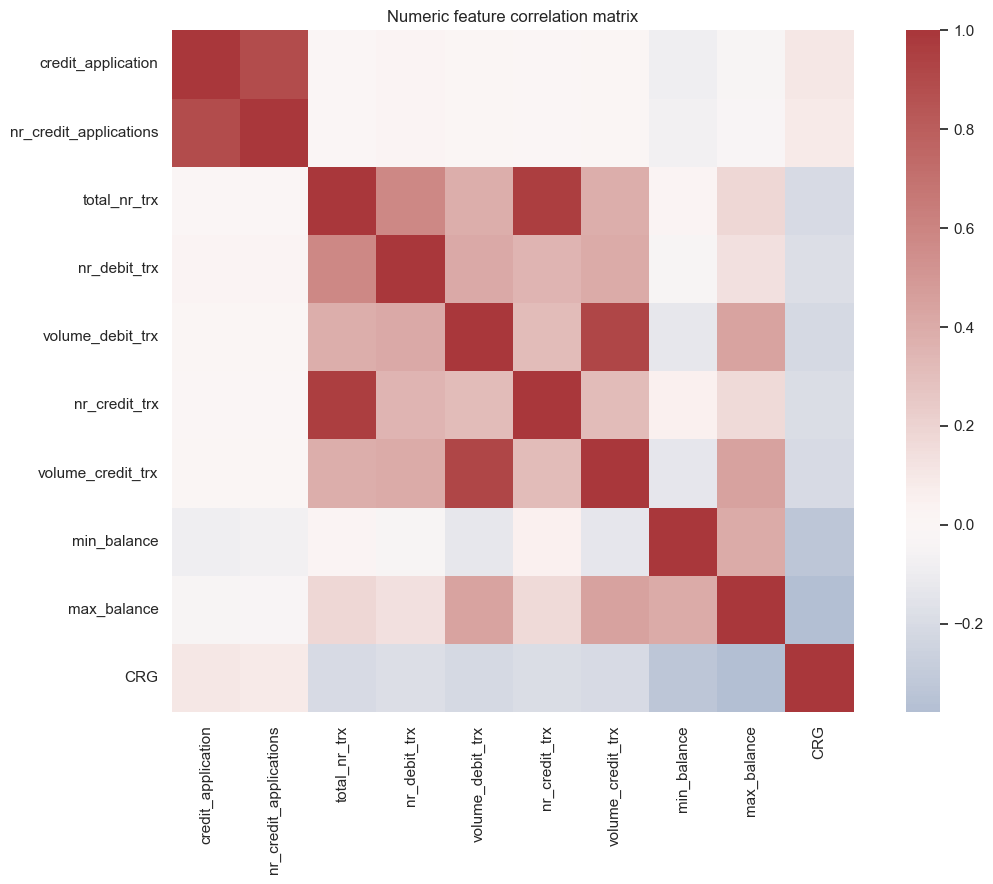

In [102]:
# Calculate the correlation matrix for all numeric columns.
correlation = eda.select_dtypes(include=np.number).corr()

# Remove index columns and client identifiers (not meaningful for correlation analysis).
columns_to_drop = ['client_nr']
columns_to_drop = [col for col in columns_to_drop if col in correlation.columns]
correlation = correlation.drop(columns=columns_to_drop, index=columns_to_drop)

# Visualize the correlation matrix as a heatmap.
plt.figure(figsize=(12, 9))
sns.heatmap(correlation, cmap='vlag', center=0, square=True, annot=False)
plt.title('Numeric feature correlation matrix')
plt.tight_layout()
plt.show()

## Time Series & Trends

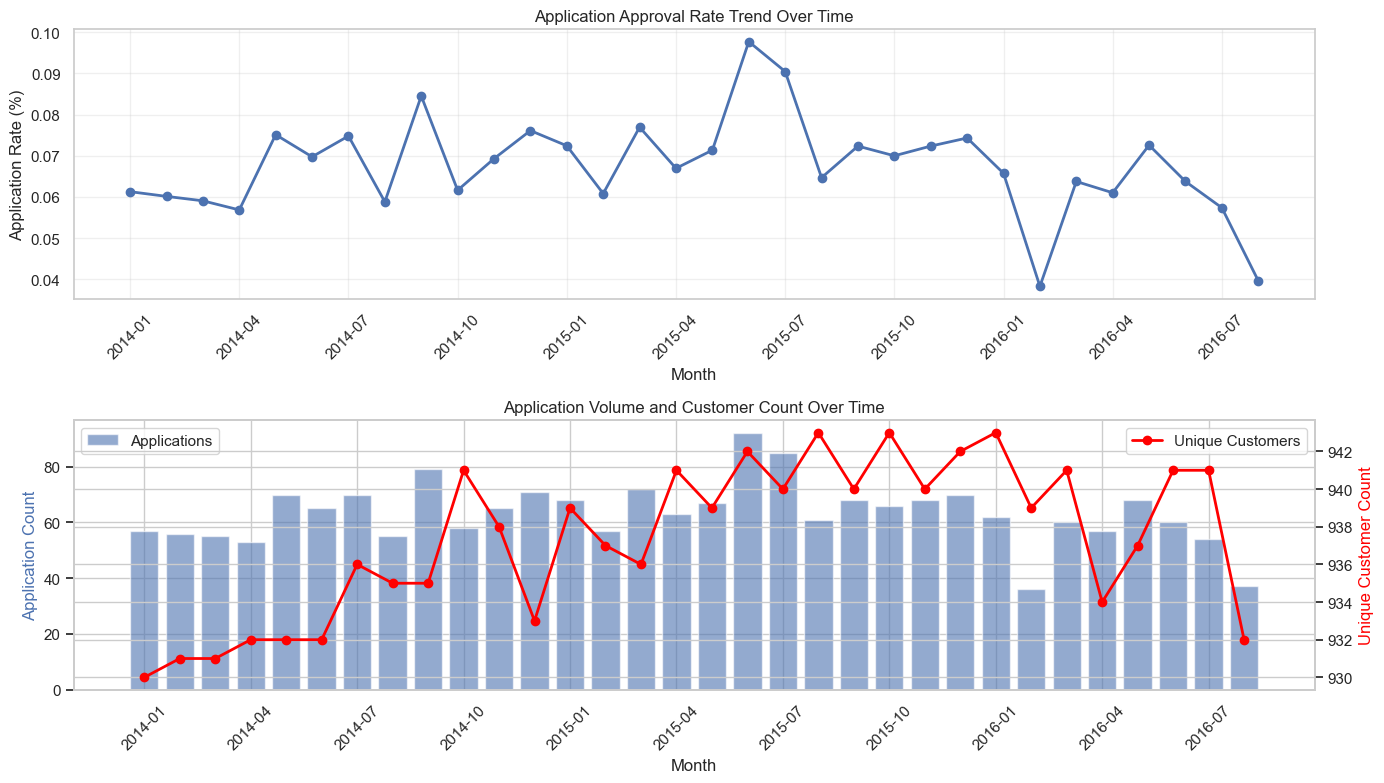

Application rate range: 0.04% - 0.10%
Average monthly applications: 63
Average unique customers per month: 937


In [103]:
# Analyze application approval rate trends over time.
approval_trends = monthly.copy()
approval_trends.index = approval_trends.index.astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot application rate trend.
axes[0].plot(range(len(approval_trends)), approval_trends['application_rate'], marker='o', linewidth=2)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Application Rate (%)')
axes[0].set_title('Application Approval Rate Trend Over Time')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(0, len(approval_trends), max(1, len(approval_trends) // 10)))
axes[0].set_xticklabels(approval_trends.index[::max(1, len(approval_trends) // 10)], rotation=45)

# Plot application volume and customer count trends.
ax2 = axes[1]
ax2.bar(range(len(approval_trends)), approval_trends['applications'], alpha=0.6, label='Applications')
ax3 = ax2.twinx()
ax3.plot(range(len(approval_trends)), approval_trends['customers'], marker='o', color='red', linewidth=2, label='Unique Customers')
ax2.set_xlabel('Month')
ax2.set_ylabel('Application Count', color='C0')
ax3.set_ylabel('Unique Customer Count', color='red')
ax2.set_title('Application Volume and Customer Count Over Time')
ax2.set_xticks(range(0, len(approval_trends), max(1, len(approval_trends) // 10)))
ax2.set_xticklabels(approval_trends.index[::max(1, len(approval_trends) // 10)], rotation=45)
ax2.legend(loc='upper left')
ax3.legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f"Application rate range: {approval_trends['application_rate'].min():.2f}% - {approval_trends['application_rate'].max():.2f}%")
print(f"Average monthly applications: {approval_trends['applications'].mean():.0f}")
print(f"Average unique customers per month: {approval_trends['customers'].mean():.0f}")

## Segmentation by Customer Risk Group

=== Application Metrics by Customer Risk Group ===



,credit_application_sum,credit_application_mean,credit_application_count,client_nr_nunique,total_nr_trx_mean,total_nr_trx_std,volume_debit_trx_mean,volume_debit_trx_std,volume_credit_trx_mean,volume_credit_trx_std,min_balance_mean,max_balance_mean
CRG,,,,,,,,,,,,
1.00,149,0.03,4424,140,203.85,162.51,"16,946,747.59","22,094,127.37","16,907,126.45","21,514,202.41","-1,273,173.58","12,257,052.20"
2.00,305,0.07,4141,136,181.57,175.38,"11,825,681.75","13,004,933.88","11,853,155.07","12,993,310.52","-2,323,824.24","5,995,316.24"
3.00,607,0.07,9097,291,156.12,110.06,"9,377,975.26","10,639,595.41","9,370,599.33","10,587,422.01","-6,195,120.67","-396,735.59"
4.00,232,0.11,2161,68,153.32,84.47,"8,085,464.67","7,756,535.95","8,063,866.33","7,749,275.25","-11,676,819.81","-2,936,677.53"
5.00,111,0.14,778,25,163.09,90.97,"9,584,033.02","9,062,198.85","9,629,262.61","8,995,004.41","-17,177,773.15","-5,126,774.86"
7.00,479,0.12,3858,138,109.56,111.19,"6,131,825.61","11,322,494.09","6,390,394.79","12,263,756.58","-13,938,051.06","-5,224,563.63"
NaN,142,0.03,5537,194,187.35,428.62,"14,177,792.68","22,975,258.74","14,327,200.26","23,431,120.97","-308,416.37","12,211,346.32"


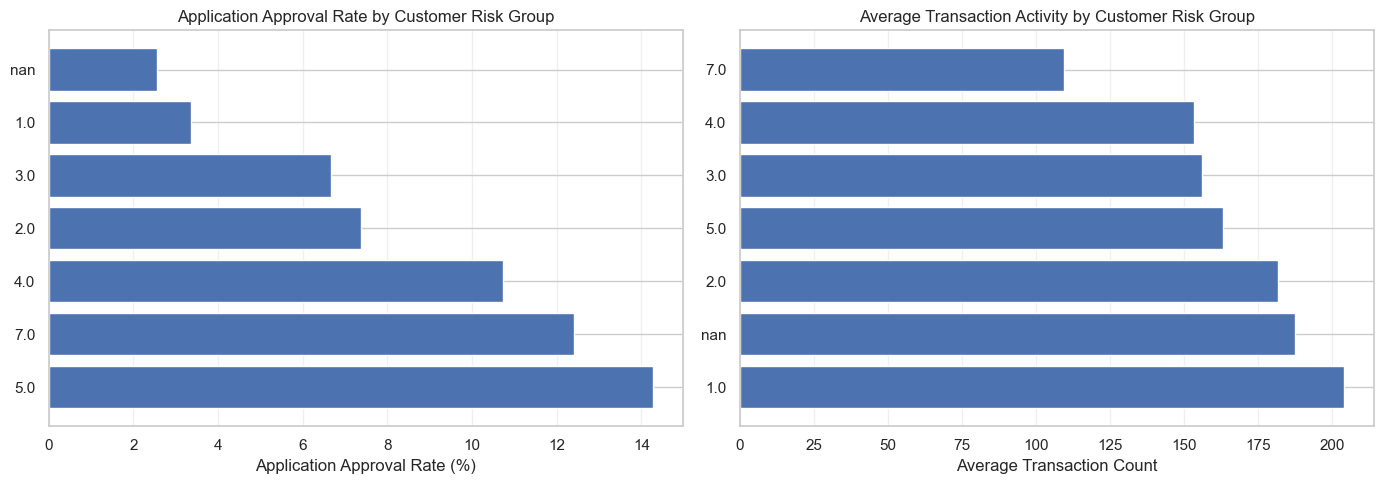

In [104]:
# Deep dive analysis by Customer Risk Group (CRG).
print("=== Application Metrics by Customer Risk Group ===\n")

crg_analysis = eda.groupby('CRG', dropna=False).agg({
    'credit_application': ['sum', 'mean', 'count'],
    'client_nr': 'nunique',
    'total_nr_trx': ['mean', 'std'],
    'volume_debit_trx': ['mean', 'std'],
    'volume_credit_trx': ['mean', 'std'],
    'min_balance': 'mean',
    'max_balance': 'mean',
}).round(2)

crg_analysis.columns = ['_'.join(col).strip() for col in crg_analysis.columns.values]
display(crg_analysis)

# Visualization: Application rate by CRG.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

crg_summary = eda.groupby('CRG', dropna=False)['credit_application'].agg(['sum', 'count', 'mean']).sort_values('mean', ascending=False)
crg_summary['mean'] *= 100

axes[0].barh(crg_summary.index.astype(str), crg_summary['mean'])
axes[0].set_xlabel('Application Approval Rate (%)')
axes[0].set_title('Application Approval Rate by Customer Risk Group')
axes[0].grid(True, alpha=0.3, axis='x')

# Transaction volume by CRG.
crg_trx = eda.groupby('CRG', dropna=False)['total_nr_trx'].mean().sort_values(ascending=False)
axes[1].barh(crg_trx.index.astype(str), crg_trx)
axes[1].set_xlabel('Average Transaction Count')
axes[1].set_title('Average Transaction Activity by Customer Risk Group')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## Outliers and Data Quality Patterns

=== Outlier and Anomaly Detection ===

               Feature  Outlier_Count  Outlier_Percentage    Lower_Bound   Upper_Bound
           max_balance           3590               11.97 -13,379,339.75 17,317,562.25
           min_balance           2170                7.23 -19,765,012.88 11,886,052.12
         nr_credit_trx           2153                7.18         -70.50        205.50
     volume_credit_trx           2054                6.85 -13,043,690.75 30,134,331.25
nr_credit_applications           2025                6.75           0.00          0.00
      volume_debit_trx           2011                6.70 -13,117,966.25 30,057,277.75
          total_nr_trx           1474                4.91        -117.50        398.50
          nr_debit_trx           1043                3.48         -56.50        195.50


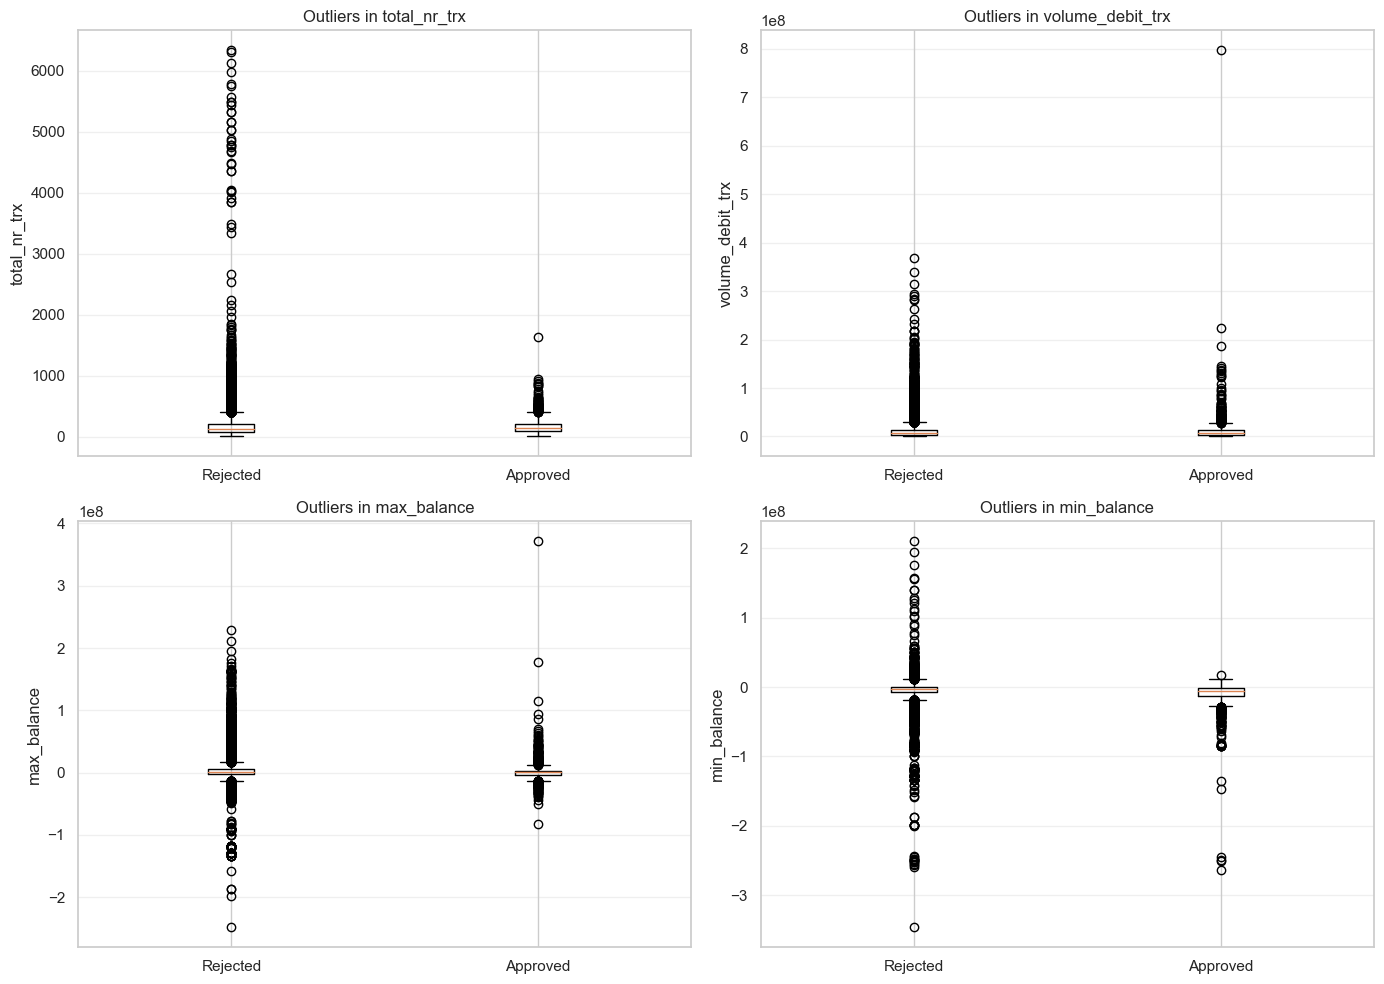


=== Clients with Zero or Low Activity ===
Records with zero transactions:
Series([], dtype: int64)

Approval rate among zero-transaction records: nan%


In [105]:
# Identify extreme values and unusual patterns.
print("=== Outlier and Anomaly Detection ===\n")

# Define outliers using IQR method.
numeric_cols = eda.select_dtypes(include=np.number).columns
outlier_summary = []

for col in numeric_cols:
    if col not in ['Unnamed: 0_application', 'Unnamed: 0_customer', 'client_nr', 'credit_application']:
        Q1 = eda[col].quantile(0.25)
        Q3 = eda[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        n_outliers = ((eda[col] < lower_bound) | (eda[col] > upper_bound)).sum()
        outlier_pct = (n_outliers / len(eda)) * 100
        
        if n_outliers > 0:
            outlier_summary.append({
                'Feature': col,
                'Outlier_Count': n_outliers,
                'Outlier_Percentage': outlier_pct,
                'Lower_Bound': lower_bound,
                'Upper_Bound': upper_bound
            })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier_Count', ascending=False)
print(outlier_df.to_string(index=False))

# Visualize outliers in key numeric features.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_features = ['total_nr_trx', 'volume_debit_trx', 'max_balance', 'min_balance']

for idx, feature in enumerate(plot_features):
    ax = axes[idx // 2, idx % 2]
    ax.boxplot([eda[eda['credit_application'] == 0][feature].dropna(),
                eda[eda['credit_application'] == 1][feature].dropna()],
               labels=['Rejected', 'Approved'])
    ax.set_ylabel(feature)
    ax.set_title(f'Outliers in {feature}')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Flag rows with zero activity.
print("\n=== Clients with Zero or Low Activity ===")
zero_activity = eda[eda['total_nr_trx'] == 0].groupby('credit_application').size()
print(f"Records with zero transactions:\n{zero_activity}")
print(f"\nApproval rate among zero-transaction records: {eda[eda['total_nr_trx'] == 0]['credit_application'].mean():.2%}")

## Customer Lifecycle and Retention

=== Customer Lifecycle Analysis ===

Total unique clients: 992
Average months active per client: 30.24
Median months active per client: 32
Repeat applicants (2+ applications): 456 (46.0%)


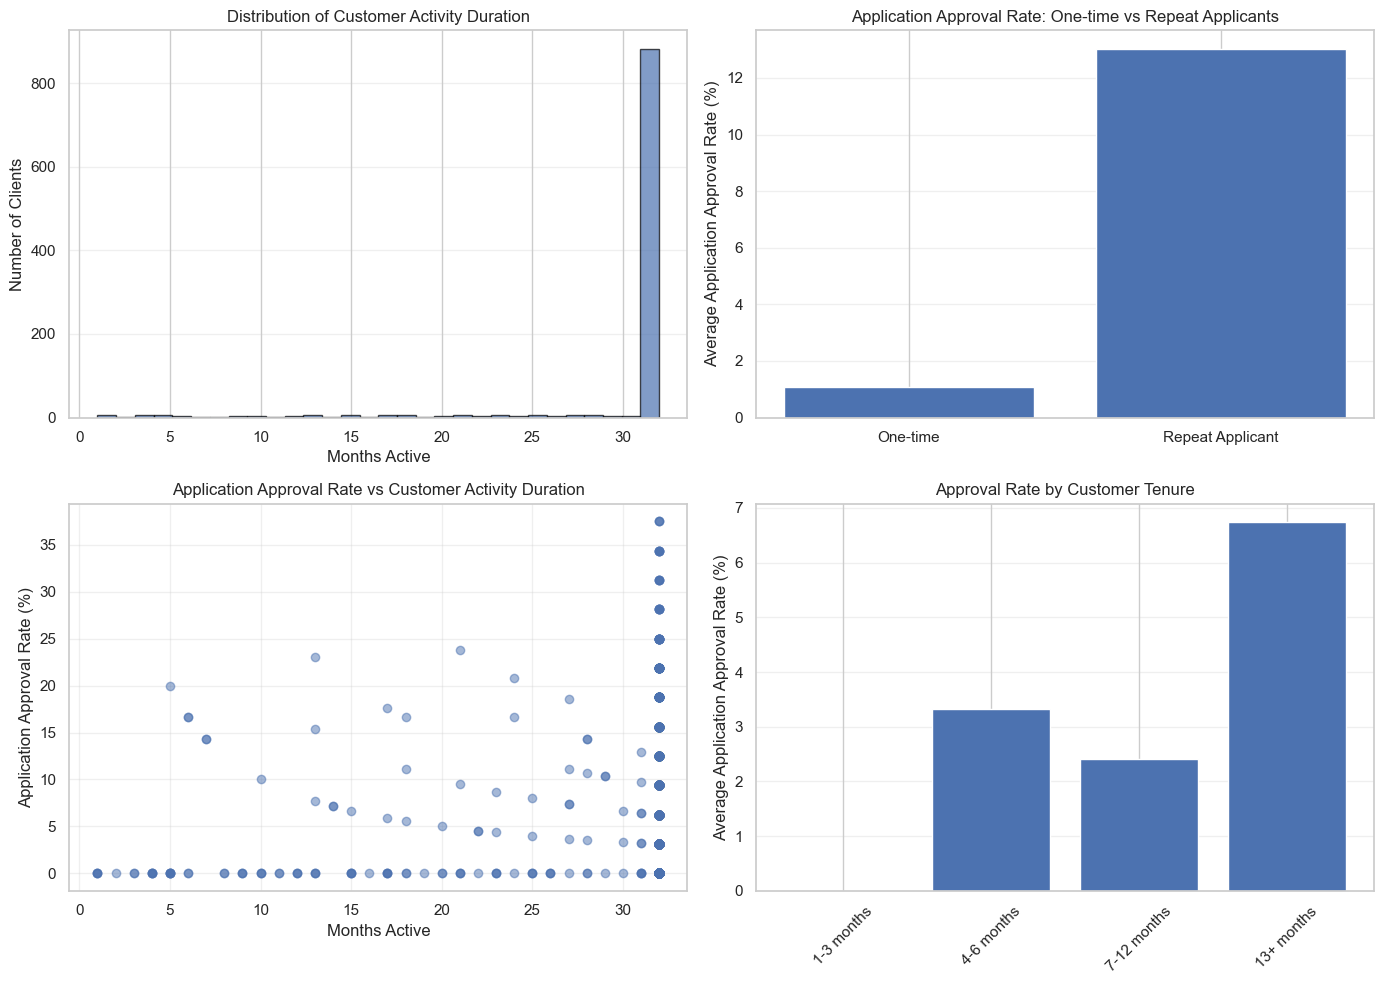


Approval rate by customer tenure:
duration_group
1-3 months    0.00
4-6 months    3.33
7-12 months   2.41
13+ months    6.74
Name: application_rate, dtype: float64


In [106]:
# Analyze customer lifecycle: activity duration and retention patterns.
print("=== Customer Lifecycle Analysis ===\n")

# For each client, calculate their observation period (first to last month with data).
client_lifecycle = eda.groupby('client_nr').agg({
    'yearmonth': ['min', 'max', 'count'],
    'credit_application': ['sum', 'count', 'mean']
}).reset_index()

client_lifecycle.columns = ['client_nr', 'first_month', 'last_month', 'month_count', 
                             'total_applications', 'total_records', 'application_rate']

# Calculate how many months each client is active.
client_lifecycle['activity_duration'] = client_lifecycle['month_count'].astype(int)
client_lifecycle['repeat_applicant'] = (client_lifecycle['total_applications'] > 1).astype(int)

print(f"Total unique clients: {len(client_lifecycle)}")
print(f"Average months active per client: {client_lifecycle['activity_duration'].mean():.2f}")
print(f"Median months active per client: {client_lifecycle['activity_duration'].median():.0f}")
print(f"Repeat applicants (2+ applications): {client_lifecycle['repeat_applicant'].sum()} ({client_lifecycle['repeat_applicant'].mean():.1%})")

# Segment by lifecycle characteristics.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution of activity duration.
axes[0, 0].hist(client_lifecycle['activity_duration'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Months Active')
axes[0, 0].set_ylabel('Number of Clients')
axes[0, 0].set_title('Distribution of Customer Activity Duration')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Repeat applicants vs one-time applicants.
repeat_summary = client_lifecycle.groupby('repeat_applicant').agg({
    'client_nr': 'count',
    'application_rate': 'mean'
})
repeat_summary.index = ['One-time', 'Repeat Applicant']
axes[0, 1].bar(repeat_summary.index, repeat_summary['application_rate'] * 100)
axes[0, 1].set_ylabel('Average Application Approval Rate (%)')
axes[0, 1].set_title('Application Approval Rate: One-time vs Repeat Applicants')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Scatter: Activity duration vs approval rate.
axes[1, 0].scatter(client_lifecycle['activity_duration'], client_lifecycle['application_rate'] * 100, alpha=0.5)
axes[1, 0].set_xlabel('Months Active')
axes[1, 0].set_ylabel('Application Approval Rate (%)')
axes[1, 0].set_title('Application Approval Rate vs Customer Activity Duration')
axes[1, 0].grid(True, alpha=0.3)

# Approval rate by activity duration groups.
client_lifecycle['duration_group'] = pd.cut(client_lifecycle['activity_duration'], 
                                             bins=[0, 3, 6, 12, float('inf')],
                                             labels=['1-3 months', '4-6 months', '7-12 months', '13+ months'])
duration_approval = client_lifecycle.groupby('duration_group')['application_rate'].mean() * 100
axes[1, 1].bar(range(len(duration_approval)), duration_approval.values)
axes[1, 1].set_xticks(range(len(duration_approval)))
axes[1, 1].set_xticklabels(duration_approval.index, rotation=45)
axes[1, 1].set_ylabel('Average Application Approval Rate (%)')
axes[1, 1].set_title('Approval Rate by Customer Tenure')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nApproval rate by customer tenure:")
print(duration_approval)